### Train model using the MNIST digit dataset with the help of Tensorflow's tf.GradientTape(). Compare the performance of the model trained by tf.GradientTape() with Tensorflow's model.fit()

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and preprocess MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train[..., tf.newaxis] / 255.0
x_test = x_test[..., tf.newaxis] / 255.0

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(64)

# Define a simple CNN model
def create_model():
    return tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10)
    ])

# Loss and optimizer
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam()

# Training loop using GradientTape
def train_with_gradient_tape(model, train_ds, test_ds, epochs=5):
    train_acc = []
    test_acc = []

    for epoch in range(epochs):
        for x_batch, y_batch in train_ds:
            with tf.GradientTape() as tape:
                logits = model(x_batch, training=True)
                loss = loss_fn(y_batch, logits)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # Evaluate
        train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy()
        test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy()

        for x_batch, y_batch in train_ds:
            train_accuracy.update_state(y_batch, model(x_batch, training=False))
        for x_batch, y_batch in test_ds:
            test_accuracy.update_state(y_batch, model(x_batch, training=False))

        train_acc.append(train_accuracy.result().numpy())
        test_acc.append(test_accuracy.result().numpy())
        print(f"Epoch {epoch+1}: Train Acc = {train_acc[-1]:.4f}, Test Acc = {test_acc[-1]:.4f}")

    return train_acc, test_acc

# Train with GradientTape
model_tape = create_model()
tape_train_acc, tape_test_acc = train_with_gradient_tape(model_tape, train_ds, test_ds)

# Train with model.fit()
model_fit = create_model()
model_fit.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
history = model_fit.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1: Train Acc = 0.9811, Test Acc = 0.9776
Epoch 2: Train Acc = 0.9863, Test Acc = 0.9792
Epoch 3: Train Acc = 0.9929, Test Acc = 0.9845
Epoch 4: Train Acc = 0.9945, Test Acc = 0.9857
Epoch 5: Train Acc = 0.9948, Test Acc = 0.9833


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8883 - loss: 0.3709 - val_accuracy: 0.9759 - val_loss: 0.0709
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9798 - loss: 0.0668 - val_accuracy: 0.9837 - val_loss: 0.0529
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9897 - loss: 0.0357 - val_accuracy: 0.9833 - val_loss: 0.0500
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9924 - loss: 0.0248 - val_accuracy: 0.9852 - val_loss: 0.0434
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9948 - loss: 0.0177 - val_accuracy: 0.9863 - val_loss: 0.0404


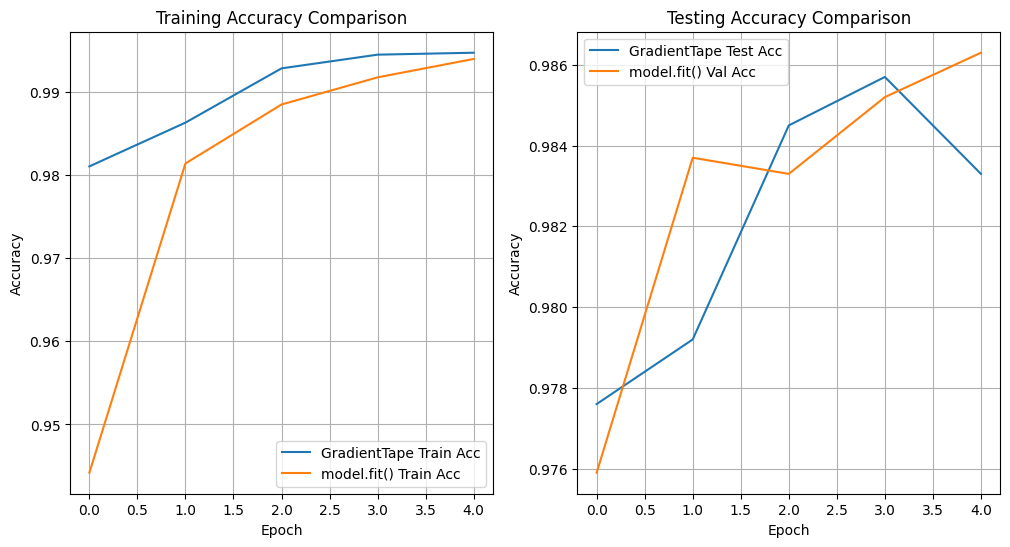

In [2]:
# Compare performance
plt.figure(figsize=(12, 6))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(tape_train_acc, label='GradientTape Train Acc')
plt.plot(history.history['accuracy'], label='model.fit() Train Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.grid(True)

# Plot testing accuracy
plt.subplot(1, 2, 2)
plt.plot(tape_test_acc, label='GradientTape Test Acc')
plt.plot(history.history['val_accuracy'], label='model.fit() Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Testing Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.show()